In [11]:
# Test del modelo XLM-RoBERTa-Large fine-tuned para análisis de sentimientos (3 clases)
# Modelo: Yenreh/xlm-roberta-large-tass-sentiment-bs{best_batch}
# Clases: 0=Negativo, 1=Neutral, 2=Positivo

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Cargar modelo y tokenizer
print("Cargando modelo desde HuggingFace...")
model_name = "Yenreh/xlm-roberta-large-tass-sentiment-bs16"  # Ajusta el batch size según el mejor modelo
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print(f"Modelo cargado: {model_name}")
print(f"Número de clases: {model.config.num_labels}")
print(f"Labels: 0=Negativo, 1=Neutral, 2=Positivo")

Cargando modelo desde HuggingFace...
Modelo cargado: Yenreh/xlm-roberta-large-tass-sentiment-bs16
Número de clases: 3
Labels: 0=Negativo, 1=Neutral, 2=Positivo
Modelo cargado: Yenreh/xlm-roberta-large-tass-sentiment-bs16
Número de clases: 3
Labels: 0=Negativo, 1=Neutral, 2=Positivo


In [12]:
# Cargar datos del dataset TASS para pruebas
import pandas as pd
import numpy as np

print("Cargando dataset TASS...\n")

# Cargar los datasets TASS
df1 = pd.read_csv("./input/TASS/cr-tass.csv")
df2 = pd.read_csv("./input/TASS/cr1-tass.csv")

# Combinar y filtrar
df = pd.concat([df1, df2], ignore_index=True)
df = df[df['label'].isin(['N', 'NEU', 'P'])].copy()
df = df.rename(columns={'sentencia original': 'text', 'label': 'sentiment'})

print(f"Dataset cargado: {len(df)} muestras\n")

Cargando dataset TASS...

Dataset cargado: 7245 muestras



In [13]:
# Pruebas con ejemplos aleatorios del dataset TASS
from transformers import pipeline

# Crear pipeline
pipe = pipeline("text-classification", model=model_name)

# Mapeo de labels
label_map = {'LABEL_0': 'Negativo', 'LABEL_1': 'Neutral', 'LABEL_2': 'Positivo'}
sentiment_map = {'N': 'Negativo', 'NEU': 'Neutral', 'P': 'Positivo'}

# Seleccionar 5 ejemplos aleatorios de cada clase
print("="*100)
print("PRUEBAS CON EJEMPLOS REALES DEL DATASET TASS")
print("="*100 + "\n")

for sentiment, label in [('N', 'NEGATIVOS'), ('NEU', 'NEUTRALES'), ('P', 'POSITIVOS')]:
    print(f"\n{'='*100}")
    print(f"TWEETS {label}")
    print("="*100 + "\n")
    
    samples = df[df['sentiment'] == sentiment].sample(n=5, random_state=42)
    
    for idx, row in samples.iterrows():
        text = row['text']
        result = pipe(text)[0]
        predicted = label_map[result['label']]
        confidence = result['score']
        
        real = sentiment_map[sentiment]
        match = "✓" if predicted == real else "✗"
        
        print(f"📝 \"{text}\"")
        print(f"   Real: {real} | Predicción: {predicted} ({confidence:.2%}) {match}\n")

print("="*100)

Device set to use cuda:0


PRUEBAS CON EJEMPLOS REALES DEL DATASET TASS


TWEETS NEGATIVOS

📝 "@Swimmer_IT sabíamos que su partida traería graves consecuencias."
   Real: Negativo | Predicción: Negativo (38.15%) ✓

📝 "Jaja Trump en los primeros 3 meses se va a traer abajo el TLC nos vamos a ir todos a la mierda"
   Real: Negativo | Predicción: Negativo (38.14%) ✓

📝 "@grumimantis20 lo digo en serio me rompes el corazón"
   Real: Negativo | Predicción: Negativo (38.15%) ✓

📝 "Ojalá que los vientos se lleven la mala suerte de la Liga eh Ok, merezco esos unfollows"
   Real: Negativo | Predicción: Negativo (38.12%) ✓

📝 "@LuisDaHernandez lo que callan los machos alfas"
   Real: Negativo | Predicción: Negativo (38.15%) ✓


TWEETS NEUTRALES

📝 "@pasku1  lo has leído?  Promulga un socialismo utópico con bases en el decrecimiento y en el arte como parte fundamental del trabajo..."
   Real: Neutral | Predicción: Negativo (38.15%) ✗

📝 "La única vez que me dormí sin tener sueño y sin ser de noche"
   Real: Neutral | Predi

In [14]:
# Resumen rápido de performance
print("\n" + "="*100)
print("RESUMEN DE PERFORMANCE")
print("="*100 + "\n")

# Probar 30 muestras aleatorias (10 por clase)
test_samples = pd.concat([
    df[df['sentiment'] == 'N'].sample(n=10, random_state=42),
    df[df['sentiment'] == 'NEU'].sample(n=10, random_state=42),
    df[df['sentiment'] == 'P'].sample(n=10, random_state=42)
])

correct = 0
total = 0
predictions_count = {'Negativo': 0, 'Neutral': 0, 'Positivo': 0}

for idx, row in test_samples.iterrows():
    result = pipe(row['text'])[0]
    predicted = label_map[result['label']]
    real = sentiment_map[row['sentiment']]
    
    predictions_count[predicted] += 1
    
    if predicted == real:
        correct += 1
    total += 1

accuracy = (correct / total) * 100

print(f"✓ Correctas: {correct}/{total} ({accuracy:.1f}%)")
print(f"✗ Incorrectas: {total-correct}/{total} ({100-accuracy:.1f}%)")

print(f"\n" + "="*100)
print("DISTRIBUCIÓN DE PREDICCIONES:")
print("="*100)
print(f"🔴 Negativo: {predictions_count['Negativo']}/{total} ({predictions_count['Negativo']/total*100:.1f}%)")
print(f"🟡 Neutral:  {predictions_count['Neutral']}/{total} ({predictions_count['Neutral']/total*100:.1f}%)")
print(f"🟢 Positivo: {predictions_count['Positivo']}/{total} ({predictions_count['Positivo']/total*100:.1f}%)")
print("\n" + "="*100)


RESUMEN DE PERFORMANCE

✓ Correctas: 16/30 (53.3%)
✗ Incorrectas: 14/30 (46.7%)

DISTRIBUCIÓN DE PREDICCIONES:
🔴 Negativo: 22/30 (73.3%)
🟡 Neutral:  0/30 (0.0%)
🟢 Positivo: 8/30 (26.7%)

✓ Correctas: 16/30 (53.3%)
✗ Incorrectas: 14/30 (46.7%)

DISTRIBUCIÓN DE PREDICCIONES:
🔴 Negativo: 22/30 (73.3%)
🟡 Neutral:  0/30 (0.0%)
🟢 Positivo: 8/30 (26.7%)



In [15]:
# Análisis de confianza por clase real
print("\n" + "="*100)
print("ANÁLISIS DE CONFIANZA DEL MODELO POR CLASE REAL")
print("="*100 + "\n")

for sentiment, label in [('N', 'NEGATIVOS'), ('NEU', 'NEUTRALES'), ('P', 'POSITIVOS')]:
    print(f"\n{'='*100}")
    print(f"ANÁLISIS: TWEETS {label}")
    print("="*100 + "\n")
    
    samples = df[df['sentiment'] == sentiment].sample(n=10, random_state=42)
    
    pred_distribution = {'Negativo': 0, 'Neutral': 0, 'Positivo': 0}
    confidence_by_pred = {'Negativo': [], 'Neutral': [], 'Positivo': []}
    
    for idx, row in samples.iterrows():
        text = row['text']
        result = pipe(text)[0]
        predicted = label_map[result['label']]
        confidence = result['score']
        
        pred_distribution[predicted] += 1
        confidence_by_pred[predicted].append(confidence)
    
    real = sentiment_map[sentiment]
    print(f"Real: {real}")
    print(f"\nPredicciones:")
    print(f"  🔴 Como Negativo: {pred_distribution['Negativo']}/10 ({pred_distribution['Negativo']*10}%)")
    print(f"  🟡 Como Neutral:  {pred_distribution['Neutral']}/10 ({pred_distribution['Neutral']*10}%)")
    print(f"  🟢 Como Positivo: {pred_distribution['Positivo']}/10 ({pred_distribution['Positivo']*10}%)")
    
    print(f"\nConfianza promedio por predicción:")
    for pred_class, confidences in confidence_by_pred.items():
        if confidences:
            avg_conf = sum(confidences) / len(confidences)
            print(f"  {pred_class}: {avg_conf:.2%}")

print("\n" + "="*100)


ANÁLISIS DE CONFIANZA DEL MODELO POR CLASE REAL


ANÁLISIS: TWEETS NEGATIVOS

Real: Negativo

Predicciones:
  🔴 Como Negativo: 10/10 (100%)
  🟡 Como Neutral:  0/10 (0%)
  🟢 Como Positivo: 0/10 (0%)

Confianza promedio por predicción:
  Negativo: 38.14%

ANÁLISIS: TWEETS NEUTRALES

Real: Neutral

Predicciones:
  🔴 Como Negativo: 8/10 (80%)
  🟡 Como Neutral:  0/10 (0%)
  🟢 Como Positivo: 2/10 (20%)

Confianza promedio por predicción:
  Negativo: 38.14%
  Positivo: 75.39%

ANÁLISIS: TWEETS POSITIVOS

Real: Positivo

Predicciones:
  🔴 Como Negativo: 4/10 (40%)
  🟡 Como Neutral:  0/10 (0%)
  🟢 Como Positivo: 6/10 (60%)

Confianza promedio por predicción:
  Negativo: 38.14%
  Positivo: 74.27%

Real: Positivo

Predicciones:
  🔴 Como Negativo: 4/10 (40%)
  🟡 Como Neutral:  0/10 (0%)
  🟢 Como Positivo: 6/10 (60%)

Confianza promedio por predicción:
  Negativo: 38.14%
  Positivo: 74.27%



In [16]:
# Ver probabilidades de todas las clases para tweets neutrales
print("\n" + "="*100)
print("ANÁLISIS DETALLADO: ¿POR QUÉ NO PREDICE NEUTRAL?")
print("="*100 + "\n")

# Tomar 5 tweets neutrales
neutral_samples = df[df['sentiment'] == 'NEU'].sample(n=5, random_state=42)

print("Viendo las probabilidades de TODAS las clases para tweets neutrales:\n")

for idx, row in neutral_samples.iterrows():
    text = row['text']
    
    # Obtener probabilidades de todas las clases
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
    
    print(f"📝 \"{text}\"")
    print(f"   Probabilidades:")
    print(f"      🔴 Negativo: {probs[0]:.2%}")
    print(f"      🟡 Neutral:  {probs[1]:.2%}")
    print(f"      🟢 Positivo: {probs[2]:.2%}")
    print(f"   Predicción: {label_map[f'LABEL_{torch.argmax(probs).item()}']}")
    print()

print("="*100)


ANÁLISIS DETALLADO: ¿POR QUÉ NO PREDICE NEUTRAL?

Viendo las probabilidades de TODAS las clases para tweets neutrales:

📝 "@pasku1  lo has leído?  Promulga un socialismo utópico con bases en el decrecimiento y en el arte como parte fundamental del trabajo..."
   Probabilidades:
      🔴 Negativo: 38.15%
      🟡 Neutral:  36.07%
      🟢 Positivo: 25.78%
   Predicción: Negativo

📝 "La única vez que me dormí sin tener sueño y sin ser de noche"
   Probabilidades:
      🔴 Negativo: 38.14%
      🟡 Neutral:  36.08%
      🟢 Positivo: 25.78%
   Predicción: Negativo

📝 "@estarc62 No podía dormir y prendí la compu a las 4am y no sé como ngaos di con tu testimonio Mariano, escuché la misma voz q tú,GRACIAS"
   Probabilidades:
      🔴 Negativo: 6.41%
      🟡 Neutral:  16.94%
      🟢 Positivo: 76.64%
   Predicción: Positivo

📝 "Tio el final de sao"
   Probabilidades:
      🔴 Negativo: 38.14%
      🟡 Neutral:  36.08%
      🟢 Positivo: 25.78%
   Predicción: Negativo

📝 "@catiquinto feliz dia de los in

In [17]:
# Probar el modelo con ejemplos aleatorios del dataset TASS
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("="*80)
print("PRUEBAS CON DATASET TASS - EJEMPLOS ALEATORIOS")
print("="*80)

# Crear pipeline
pipe = pipeline("text-classification", model=model_name)

# Mapeo de labels
label_map = {
    'LABEL_0': 'Negativo',
    'LABEL_1': 'Neutral', 
    'LABEL_2': 'Positivo'
}

sentiment_to_label = {
    'N': 'Negativo',
    'NEU': 'Neutral',
    'P': 'Positivo'
}

# Seleccionar muestras aleatorias de cada clase (10 por clase)
n_samples = 10
print(f"\nSeleccionando {n_samples} muestras aleatorias de cada clase...\n")

samples_neg = df[df['sentiment'] == 'N'].sample(n=n_samples, random_state=42)
samples_neu = df[df['sentiment'] == 'NEU'].sample(n=n_samples, random_state=42)
samples_pos = df[df['sentiment'] == 'P'].sample(n=n_samples, random_state=42)

# Combinar todas las muestras
test_samples = pd.concat([samples_neg, samples_neu, samples_pos]).reset_index(drop=True)

print("="*80)
print("RESULTADOS DE LAS PRUEBAS (30 MUESTRAS ALEATORIAS):")
print("="*80 + "\n")

predictions = []
true_labels = []
correct = 0
total = 0

for idx, row in test_samples.iterrows():
    text = row['text']
    true_sentiment = sentiment_to_label[row['sentiment']]
    
    # Predicción
    result = pipe(text)[0]
    predicted = label_map[result['label']]
    confidence = result['score']
    
    # Guardar para métricas
    predictions.append(predicted)
    true_labels.append(true_sentiment)
    
    # Determinar si es correcta
    is_correct = predicted == true_sentiment
    if is_correct:
        correct += 1
    total += 1
    
    match = "✓" if is_correct else "✗"
    
    print(f"{idx+1}. Texto: \"{text[:100]}{'...' if len(text) > 100 else ''}\"")
    print(f"   Real: {true_sentiment} | Predicción: {predicted} (conf: {confidence:.4f}) {match}")
    print()

# Calcular métricas generales
accuracy = correct / total
print("\n" + "="*80)
print("MÉTRICAS DE EVALUACIÓN:")
print("="*80)
print(f"\nAccuracy: {accuracy:.4f} ({correct}/{total} correctas)")

# F1 Score y métricas por clase
from sklearn.metrics import classification_report
print("\nReporte de clasificación:")
print(classification_report(true_labels, predictions, 
                          target_names=['Negativo', 'Neutral', 'Positivo'],
                          zero_division=0))

PRUEBAS CON DATASET TASS - EJEMPLOS ALEATORIOS


Device set to use cuda:0



Seleccionando 10 muestras aleatorias de cada clase...

RESULTADOS DE LAS PRUEBAS (30 MUESTRAS ALEATORIAS):

1. Texto: "@Swimmer_IT sabíamos que su partida traería graves consecuencias."
   Real: Negativo | Predicción: Negativo (conf: 0.3815) ✓

2. Texto: "Jaja Trump en los primeros 3 meses se va a traer abajo el TLC nos vamos a ir todos a la mierda"
   Real: Negativo | Predicción: Negativo (conf: 0.3814) ✓

3. Texto: "@grumimantis20 lo digo en serio me rompes el corazón"
   Real: Negativo | Predicción: Negativo (conf: 0.3815) ✓

4. Texto: "Ojalá que los vientos se lleven la mala suerte de la Liga eh Ok, merezco esos unfollows"
   Real: Negativo | Predicción: Negativo (conf: 0.3812) ✓

5. Texto: "@LuisDaHernandez lo que callan los machos alfas"
   Real: Negativo | Predicción: Negativo (conf: 0.3815) ✓

6. Texto: "Ha eirado mi paquete sl200 chales hubiera aprovechado el mes gratis de la llamada que me pedía mis d..."
   Real: Negativo | Predicción: Negativo (conf: 0.3814) ✓

7. Texto: "

MATRIZ DE CONFUSIÓN


                    Pred Neg     Pred Neu     Pred Pos
Real Negativo             10            0            0
Real Neutral               8            0            2
Real Positivo              4            0            6


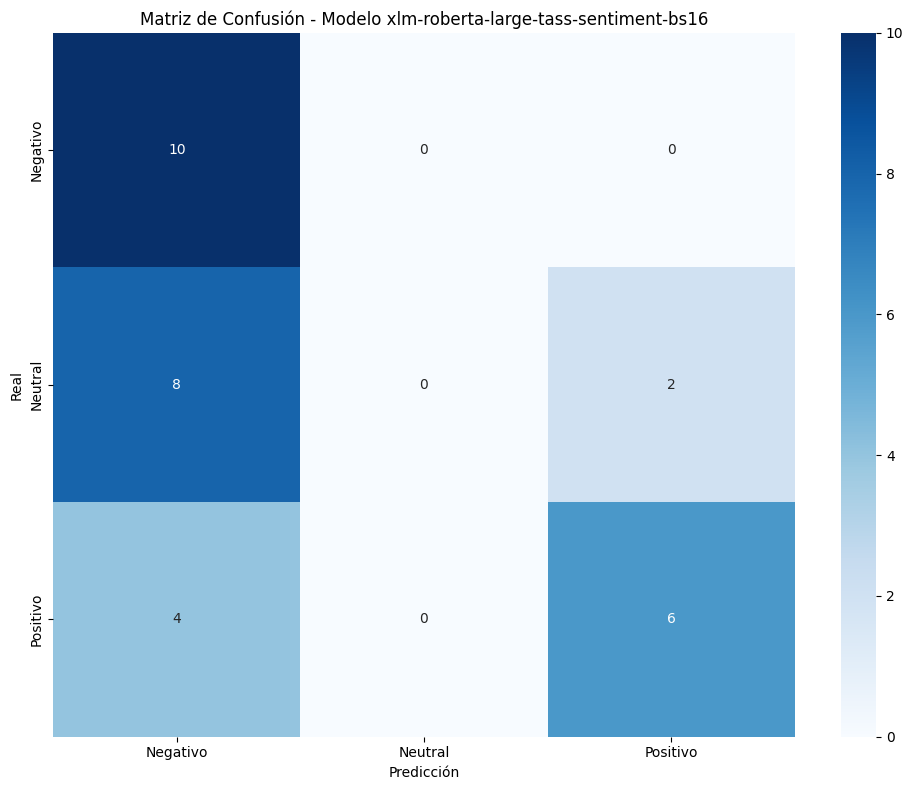


ANÁLISIS:
✓ Correctas: 16 (53.3%)
✗ Incorrectas: 14 (46.7%)


In [18]:
# Visualizar matriz de confusión
print("="*80)
print("MATRIZ DE CONFUSIÓN")
print("="*80)

# Calcular matriz de confusión
cm = confusion_matrix(true_labels, predictions, 
                     labels=['Negativo', 'Neutral', 'Positivo'])

print("\n")
print(f"{'':15} {'Pred Neg':>12} {'Pred Neu':>12} {'Pred Pos':>12}")
print(f"{'Real Negativo':<15} {cm[0,0]:>12} {cm[0,1]:>12} {cm[0,2]:>12}")
print(f"{'Real Neutral':<15} {cm[1,0]:>12} {cm[1,1]:>12} {cm[1,2]:>12}")
print(f"{'Real Positivo':<15} {cm[2,0]:>12} {cm[2,1]:>12} {cm[2,2]:>12}")

# Graficar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión - Modelo {model_name.split("/")[-1]}')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANÁLISIS:")
print("="*80)
print(f"✓ Correctas: {correct} ({correct/total*100:.1f}%)")
print(f"✗ Incorrectas: {total-correct} ({(total-correct)/total*100:.1f}%)")

EVALUACIÓN EXTENDIDA - 100 MUESTRAS ALEATORIAS

Evaluando 100 muestras...
Ejecutando predicciones...

RESULTADOS DE EVALUACIÓN EXTENDIDA:

Accuracy: 0.5000
F1 Score (weighted): 0.4097

REPORTE DETALLADO POR CLASE:
              precision    recall  f1-score   support

    Negativo       0.41      0.91      0.57        33
     Neutral       0.00      0.00      0.00        33
    Positivo       0.74      0.59      0.66        34

    accuracy                           0.50       100
   macro avg       0.38      0.50      0.41       100
weighted avg       0.39      0.50      0.41       100

MATRIZ DE CONFUSIÓN (100 MUESTRAS):

                    Pred Neg     Pred Neu     Pred Pos
Real Negativo             30            0            3
Real Neutral              29            0            4
Real Positivo             14            0           20

RESULTADOS DE EVALUACIÓN EXTENDIDA:

Accuracy: 0.5000
F1 Score (weighted): 0.4097

REPORTE DETALLADO POR CLASE:
              precision    recall  

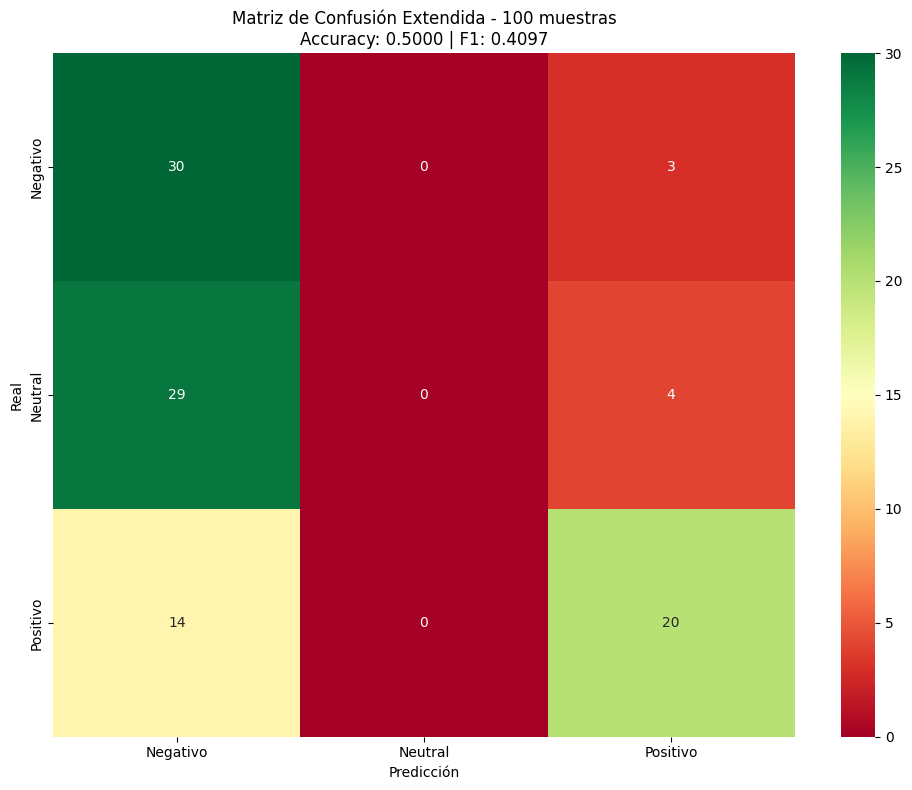

In [19]:
# Pruebas más extensivas (100 muestras aleatorias)
print("="*80)
print("EVALUACIÓN EXTENDIDA - 100 MUESTRAS ALEATORIAS")
print("="*80)

# Seleccionar 100 muestras aleatorias estratificadas
n_samples_extended = 33  # ~33 por clase para tener 100 total

samples_neg_ext = df[df['sentiment'] == 'N'].sample(n=n_samples_extended, random_state=123)
samples_neu_ext = df[df['sentiment'] == 'NEU'].sample(n=n_samples_extended, random_state=123)
samples_pos_ext = df[df['sentiment'] == 'P'].sample(n=n_samples_extended+1, random_state=123)  # 34 para completar 100

test_samples_ext = pd.concat([samples_neg_ext, samples_neu_ext, samples_pos_ext]).reset_index(drop=True)

print(f"\nEvaluando {len(test_samples_ext)} muestras...")

predictions_ext = []
true_labels_ext = []

# Procesar en batch para mayor eficiencia
texts = test_samples_ext['text'].tolist()
true_sentiments = test_samples_ext['sentiment'].tolist()

print("Ejecutando predicciones...")
results = pipe(texts)

for i, (result, true_sent) in enumerate(zip(results, true_sentiments)):
    predicted = label_map[result['label']]
    true_label = sentiment_to_label[true_sent]
    
    predictions_ext.append(predicted)
    true_labels_ext.append(true_label)

# Calcular métricas
accuracy_ext = accuracy_score(true_labels_ext, predictions_ext)
f1_ext = f1_score(true_labels_ext, predictions_ext, average='weighted')

print("\n" + "="*80)
print("RESULTADOS DE EVALUACIÓN EXTENDIDA:")
print("="*80)
print(f"\nAccuracy: {accuracy_ext:.4f}")
print(f"F1 Score (weighted): {f1_ext:.4f}")

print("\n" + "="*80)
print("REPORTE DETALLADO POR CLASE:")
print("="*80)
print(classification_report(true_labels_ext, predictions_ext,
                          target_names=['Negativo', 'Neutral', 'Positivo'],
                          zero_division=0))

# Matriz de confusión extendida
cm_ext = confusion_matrix(true_labels_ext, predictions_ext,
                         labels=['Negativo', 'Neutral', 'Positivo'])

print("="*80)
print("MATRIZ DE CONFUSIÓN (100 MUESTRAS):")
print("="*80)
print(f"\n{'':15} {'Pred Neg':>12} {'Pred Neu':>12} {'Pred Pos':>12}")
print(f"{'Real Negativo':<15} {cm_ext[0,0]:>12} {cm_ext[0,1]:>12} {cm_ext[0,2]:>12}")
print(f"{'Real Neutral':<15} {cm_ext[1,0]:>12} {cm_ext[1,1]:>12} {cm_ext[1,2]:>12}")
print(f"{'Real Positivo':<15} {cm_ext[2,0]:>12} {cm_ext[2,1]:>12} {cm_ext[2,2]:>12}")

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión Extendida - 100 muestras\nAccuracy: {accuracy_ext:.4f} | F1: {f1_ext:.4f}')
plt.tight_layout()
plt.show()